Develop:

* beta dose heterogeneity. Fixed deviation for grains in a layer, new deviation for new grains. Base deviation on position in array, or are the positions mixed with transport?
* Depth function for bleaching. Assign each grain a depth based on their layer? Use light attenuation equations 
* dry dose rate: 
    * fix doses with depth, instead of per layer that have variable thickni
    * mix dry dose rates as well?
    * count number of resets of beta_dose_heterogeneity due to BT. How many grains per layer have a reset value and how does that contribute to overall uncertainty? I would expect uncertainty to drop in mixing zone, but that is not the case


# Setup

In [ ]:
include("Mixed-Signals_functions.jl")


## Define objects and parameters for soil and luminescence
bd = 1500               # Bulk density [kg m⁻³]
soildepth = 2           # Thickness of the entire soil profile [m]
nlayers = 100           # Number of soil layers
layer_thickness = 0.02  # Initial layer thickness [m]
bleaching_depth = 0.005 # Thickness of surface layer where bleaching occurs [m]
grains_per_layer = 200  # Initial number of layers per soil layer
beta_dose_variation = 0.3 # standard error of beta dose heterogeneity
dt = 1

# Define process-specific parameters 
BT_pot = 10             # Potential bioturbation rate [kg m⁻² a⁻¹]
dd = 1                  # Depth parameter [m⁻¹]
dd_exch = 10            # Depth parameter for subsurface mixing [m⁻¹]
ntime = 10000           # Number of simulation years


soil, ages = initialise_soil(soildepth, nlayers, layer_thickness, bleaching_depth, grains_per_layer)

dry_dose_rate = range(10, 3, nlayers) ./ 1000 # Gy a-1
# dry_dose_rate = fill(3, nlayers)
dry_dose_rate

([0.005 7.5 0.0025 0.005; 0.02 30.0 0.015 0.025; … ; 0.02 30.0 1.9550000000000014 1.9650000000000012; 0.0349999999999986 52.499999999997904 1.9825000000000008 1.9999999999999998], [[0.0 0.0 0.0 0.9649035140689353; 0.0 0.0 0.0 0.6427130199691895; … ; 0.0 0.0 0.0 1.3941593174611975; 0.0 0.0 0.0 0.9136570640750696], [0.0 0.0 0.0 1.2733029916571903; 0.0 0.0 0.0 0.9861266208884654; … ; 0.0 0.0 0.0 1.0375515641361621; 0.0 0.0 0.0 1.026267466146681], [0.0 0.0 0.0 1.1594059531434977; 0.0 0.0 0.0 0.7355329626724845; … ; 0.0 0.0 0.0 0.9344552761972709; 0.0 0.0 0.0 1.2184565751493543], [0.0 0.0 0.0 1.5868161582686329; 0.0 0.0 0.0 0.480350233428377; … ; 0.0 0.0 0.0 0.9377974473085123; 0.0 0.0 0.0 0.6732221820363514], [0.0 0.0 0.0 0.9414318875940876; 0.0 0.0 0.0 0.8520377475339737; … ; 0.0 0.0 0.0 1.0097733364929158; 0.0 0.0 0.0 1.297830614092444], [0.0 0.0 0.0 1.0357464906489853; 0.0 0.0 0.0 1.448490016396118; … ; 0.0 0.0 0.0 0.9814750065106491; 0.0 0.0 0.0 0.9554348068782275], [0.0 0.0 0.0 1.2061

In [434]:
# Test with bioturbation
nlayers = 250
soildepth = 5
dd_grd = 1

dry_dose_rate = range(10, 3, nlayers) ./ 1000 # Gy a-1
dry_dose_rate  = fill(3, nlayers) / 1000
soil, ages = initialise_soil(soildepth, nlayers, layer_thickness, bleaching_depth, grains_per_layer)

for t in 1:1000
    soil, ages = BT_mounding(soil, ages, 5, "grd", dd_grd)
    # soil, ages = BT_mixing(soil, ages, 5, "grd", 1)
    soil, ages = update_soil_and_luminescence(soil, ages)
end

# Different plots

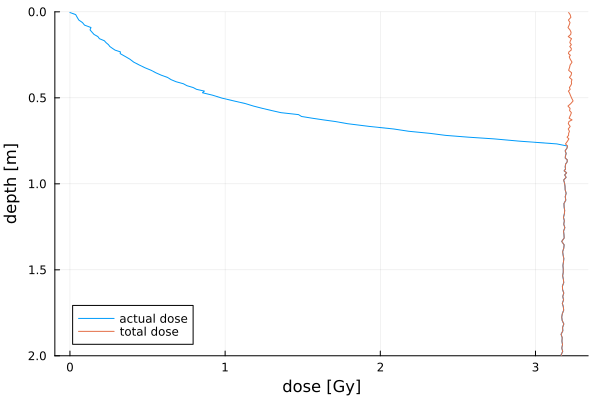

In [ ]:
# Plots 
median1 = [median(sub[:,2]) for sub in ages]
std1 = [std(sub[:,2]) for sub in ages]
median2 = [median(sub[:,3]) for sub in ages]
std2 = [std(sub[:,3]) for sub in ages]
depths  = soil[:,3]

plot(median1, depths, label = "actual dose", xlab = "dose [Gy]", ylim = (0,2), ylab = "depth [m]", legend=:bottomleft); yflip!(true)
plot!(median2, depths, label = "total dose")


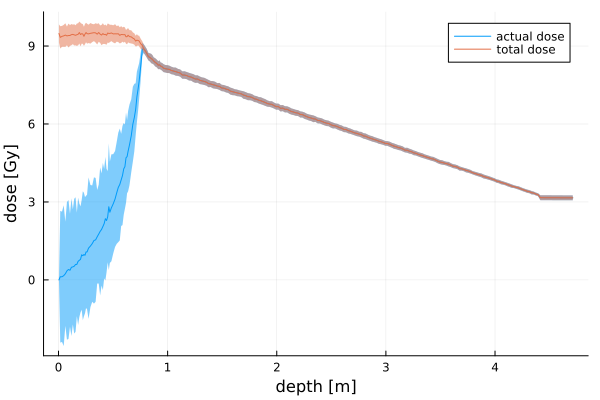

In [419]:
plot(depths, median1, ribbon = std1, label = "actual dose", xlab = "depth [m]", ylab = "dose [Gy]")
plot!(depths, median2, ribbon = std2, label = "total dose")

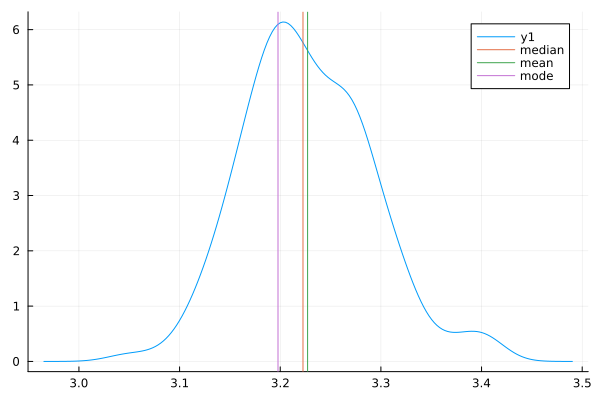

In [448]:
layer = 5
index = 3
StatsPlots.density(ages[layer][:,index])
vline!([median(ages[layer][:,index])], label = "median")
vline!([mean(ages[layer][:,index])], label = "mean")
vline!([mode(ages[layer][:,index])], label = "mode")

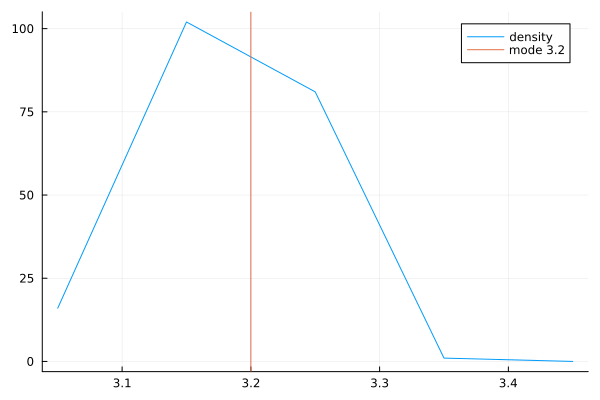

In [447]:
# dens_1, mode_1 = density_interval(rand(Normal(100,20), 1000000), 1)
dens_1, mode_1 = density_interval(ages[100][:,2], .1)
plot(dens_1[:,1], dens_1[:,2], label = "density")
vline!([mode_1], label = "mode " * string(mode_1))



In [342]:
ages[4][:,3]

148-element Vector{Float64}:
 9014.218232062034
 7234.452519880253
 8728.200989425539
 6961.1642623786165
 7507.320850911881
 8204.162400117086
 8754.046418198439
 7762.294137787707
 8275.832487794723
 8716.975099899058
    ⋮
 7371.831015314317
 8693.878932705127
 8611.17256745428
 8311.766960261197
 7948.07966767296
 8089.729763522958
 7484.485752152215
 7601.228255191714
 7881.477074222812

# Experiment 1. beta dose heterogeneity without mixing

* Fixed dose rate of 3 Gy/ka + cosmic
* beta dose variation = 0.3 (standard error)
* Run of 10000 years without mixing

In [96]:
include("Mixed-Signals_functions.jl")

## Define objects and parameters for soil and luminescence
bd = 1500               # Bulk density [kg m⁻³]
soildepth = 4           # Thickness of the entire soil profile [m]
nlayers = 400           # Number of soil layers
layer_thickness = 0.02  # Initial layer thickness [m]
bleaching_depth = 0.005 # Thickness of surface layer where bleaching occurs [m]
grains_per_layer = 200  # Initial number of layers per soil layer
beta_dose_variation = 0.3 # standard error of beta dose heterogeneity
dt = 1

# Define process-specific parameters 
BT_pot = 10             # Potential bioturbation rate [kg m⁻² a⁻¹]
dd = 1                  # Depth parameter [m⁻¹]
dd_exch = 10            # Depth parameter for subsurface mixing [m⁻¹]
ntime = 10000           # Number of simulation years


soil, ages = initialise_soil(soildepth, nlayers, layer_thickness, bleaching_depth, grains_per_layer)

doses_out = zeros(Float64, nlayers, 0)
sd_doses_out = zeros(Float64, nlayers, 0)
dry_dose_rate = fill(3, nlayers) / 1000

for t in 1:100
    soil, ages = update_soil_and_luminescence(soil, ages)
    doses_out = hcat(doses_out, [mean(sub[:,3]) for sub in ages])
    sd_doses_out = hcat(sd_doses_out, [std(sub[:,3]) for sub in ages])
end

doses_out

400×100 Matrix{Float64}:
   0.00324595    0.0064919   …    0.318103    0.321349    0.324595
   0.00332046    0.00664091       0.325405    0.328725    0.332046
   0.00332142    0.00664283       0.325499    0.32882     0.332142
   0.00325682    0.00651364       0.319168    0.322425    0.325682
   0.00345528    0.00691057       0.338618    0.342073    0.345528
   0.00326428    0.00652855  …    0.319899    0.323163    0.326428
   0.00328809    0.00657618       0.322233    0.325521    0.328809
   0.00334174    0.00668347       0.32749     0.330832    0.334174
   0.00322136    0.00644271       0.315693    0.318914    0.322136
   0.00329069    0.00658139       0.322488    0.325779    0.329069
   ⋮                         ⋱                          
 NaN           NaN              NaN         NaN         NaN
 NaN           NaN              NaN         NaN         NaN
 NaN           NaN              NaN         NaN         NaN
 NaN           NaN              NaN         NaN         NaN
 NaN    

## Calculate spread in doses along the profile and through time

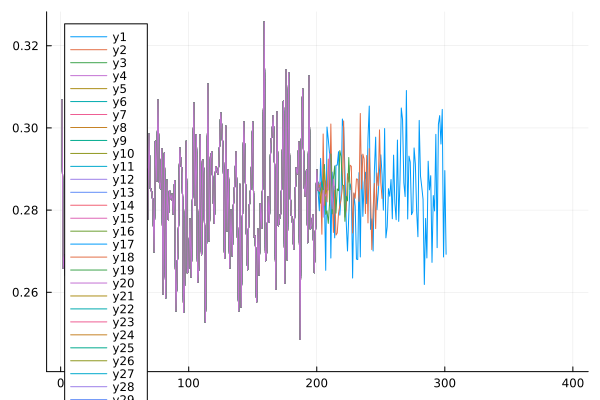

In [97]:
plot(sd_doses_out ./ doses_out)


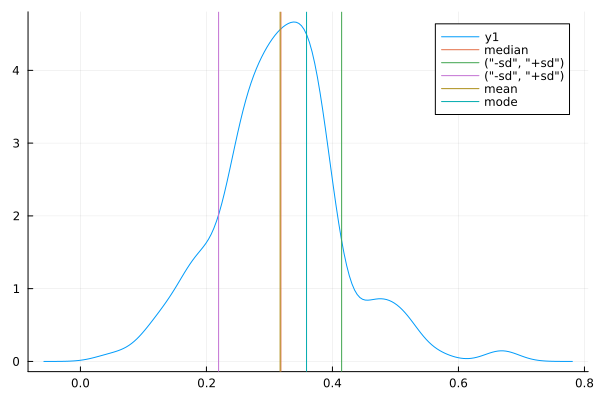

In [118]:
layer = 20
index = 3
StatsPlots.density(ages[layer][:,index])
vline!([median(ages[layer][:,index])], label = "median")
vline!([[mean(ages[layer][:,index])] + [std(ages[layer][:,index])], [mean(ages[layer][:,index])] - [std(ages[layer][:,index])]], label = ("-sd", "+sd"))
vline!([mean(ages[layer][:,index])], label = "mean")
vline!([mode(ages[layer][:,index])], label = "mode")

1×1 Matrix{Float64}:
 0.30679161350097744

## now with subsurface mixing

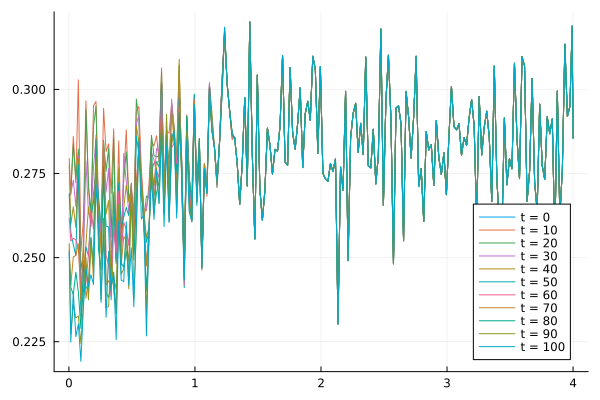

In [144]:
include("Mixed-Signals_functions.jl")

soil_m, ages_m = initialise_soil(soildepth, nlayers, layer_thickness, bleaching_depth, grains_per_layer)

doses_out_m = zeros(Float64, nlayers, 0)
sd_doses_out_m = zeros(Float64, nlayers, 0)

plt = plot(soil_m[:,3], [std(sub[:,3]) for sub in ages_m] ./ [safe_median(sub[:,3]) for sub in ages_m], label = "t = 0", legend=:bottomright)

for t in 1:100
    soil_m, ages_m = BT_mixing(soil_m, ages_m,10, "grd", 1)
    soil_m, ages_m = update_soil_and_luminescence(soil_m, ages_m)
    doses_out_m = hcat(doses_out_m, [safe_median(sub[:,3]) for sub in ages_m])
    sd_doses_out_m = hcat(sd_doses_out_m, [std(sub[:,3]) for sub in ages_m])

    if(t % 10 == 0)
        plt = plot!(soil_m[:,3], [std(sub[:,3]) for sub in ages_m] ./ [safe_median(sub[:,3]) for sub in ages_m], label = "t = " * string(t))
    end
end

plt

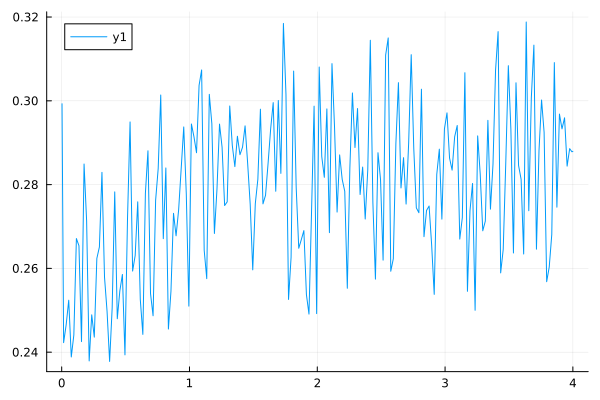

In [124]:
relsd = sd_doses_out_m ./ doses_out_m
doses = mean(relsd, dims = 2)
depths = soil[:,3]

plot(depths, doses)

## and mounding

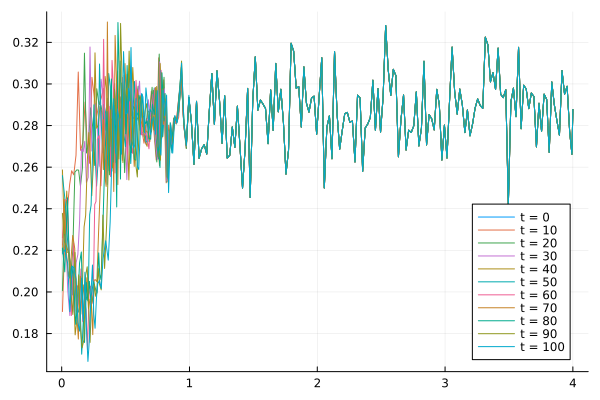

In [143]:

include("Mixed-Signals_functions.jl")

soil_m, ages_m = initialise_soil(soildepth, nlayers, layer_thickness, bleaching_depth, grains_per_layer)

doses_out_m = zeros(Float64, nlayers, 0)
sd_doses_out_m = zeros(Float64, nlayers, 0)

plt = plot(soil_m[:,3], [std(sub[:,3]) for sub in ages_m] ./ [safe_median(sub[:,3]) for sub in ages_m], label = "t = 0", legend=:bottomright)

for t in 1:100
    soil_m, ages_m = BT_mounding(soil_m, ages_m,10, "grd", 1)
    soil_m, ages_m = update_soil_and_luminescence(soil_m, ages_m)
    doses_out_m = hcat(doses_out_m, [safe_median(sub[:,3]) for sub in ages_m])
    sd_doses_out_m = hcat(sd_doses_out_m, [std(sub[:,3]) for sub in ages_m])

    if(t % 10 == 0)
        plt = plot!(soil_m[:,3], [std(sub[:,3]) for sub in ages_m] ./ [safe_median(sub[:,3]) for sub in ages_m], label = "t = " * string(t))
    end
end

plt

In [138]:
doses_out_m

400×100 Matrix{Union{Missing, Float64}}:
 0.00329461  0.00612125  0.00948978  …  0.324323  0.31836   0.324861
 0.00332315  0.00657731  0.010082       0.312195  0.316726  0.318371
 0.00333641  0.00669049  0.00966431     0.320364  0.324874  0.328106
 0.00330705  0.00660684  0.0100377      0.333556  0.335934  0.338433
 0.00328945  0.00654891  0.00993738     0.314862  0.318442  0.321498
 0.00336279  0.00670839  0.00982082  …  0.322217  0.325559  0.32864
 0.00325865  0.00651587  0.0100677      0.3163    0.317647  0.323671
 0.00329482  0.00658834  0.00975        0.330016  0.333713  0.33681
 0.0033369   0.00667357  0.00988336     0.31516   0.320238  0.325987
 0.00327182  0.00654258  0.0100072      0.323808  0.326444  0.329324
 ⋮                                   ⋱                      
  missing     missing     missing        missing   missing   missing
  missing     missing     missing        missing   missing   missing
  missing     missing     missing        missing   missing   missing
  m

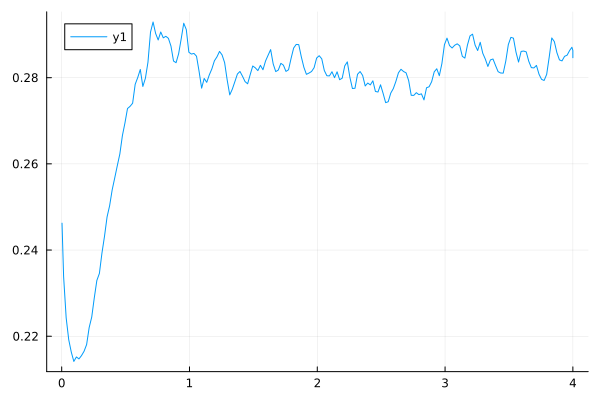

In [139]:
relsd = sd_doses_out_m ./ doses_out_m
doses = mean(relsd, dims = 2)
depths = soil[:,3]

plot(depths, doses)

In [105]:
layer = 199
std(ages_m[layer][:,3]) / mean(ages_m[layer][:,3])

0.2628577057420475

0


0